Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Connect colab with google drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Merge dataset


In [3]:
import os

folder_path = '/content/drive/MyDrive/AuthentiText/dataset'
files = os.listdir(folder_path)

dataset = []

for file in files:
  if file.endswith('.csv'):
    path = os.path.join(folder_path,file)

    temp_df = pd.read_csv(path)
    dataset.append(temp_df)

final_dataset = pd.concat(dataset, ignore_index = True)

final_dataset.head()

,question,text,label,source,domain
0,Your Honest reaction when any class gets cance...,When our Database Management Systems class get...,1,deepseek,class_cancellation
1,Your Honest reaction when any class gets cance...,I have mixed feelings whenever our Operating S...,1,deepseek,class_cancellation
2,Your Honest reaction when any class gets cance...,"Honestly, when Statistics for Engineers got ca...",1,deepseek,class_cancellation
3,Your Honest reaction when any class gets cance...,"When our Psychology 101 lecture got scrapped, ...",1,deepseek,class_cancellation
4,Your Honest reaction when any class gets cance...,"Oh man, Advanced Calculus getting cancelled is...",1,deepseek,class_cancellation


In [4]:
final_dataset.shape

(1906, 5)

final_dataset as csv file

In [5]:
final_dataset.to_csv(
    '/content/drive/MyDrive/AuthentiText/final_dataset.csv',
    index = False
)

#Exploratory Data Analysis (part-1)
---
##Basic dataset understanding


Check columns

In [6]:
final_dataset.columns

Index(['question', 'text', 'label', 'source', 'domain'], dtype='object')

Data informations


In [7]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1906 entries, 0 to 1905
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1906 non-null   object
 1   text      1906 non-null   object
 2   label     1906 non-null   int64 
 3   source    1906 non-null   object
 4   domain    1906 non-null   object
dtypes: int64(1), object(4)
memory usage: 74.6+ KB


Check missing values

In [8]:
final_dataset.isnull().sum()

,0
question,0
text,0
label,0
source,0
domain,0


Check duplicate

In [9]:
final_dataset.duplicated().sum()

# remove duplicate

final_dataset = final_dataset.drop_duplicates()

Label distribution
- Human = 0
- AI = 1

In [10]:
print(final_dataset['label'].value_counts(),'\n')

print(final_dataset.groupby('label')['source'].value_counts(),'\n')

label
1    959
0    946
Name: count, dtype: int64 

label  source    
0      human         756
       imdb          150
       amazon         40
1      chatgpt       192
       claude        192
       deepseek      192
       gemini        192
       perplexity    191
Name: count, dtype: int64 



#Exploratory Data Analysis (part-2)
---
##Domain distribution


Counting total no. of domains

In [11]:
domain_count = final_dataset['domain'].value_counts()
print('Total domain: ', final_dataset['domain'].nunique())
print(domain_count)

Total domain:  8
domain
social_media          440
movie_review          299
communication         220
class_cancellation    220
growing_up            220
transportation        214
exam_experience       212
product_review         80
Name: count, dtype: int64


##Visualization (EDA through graphs)

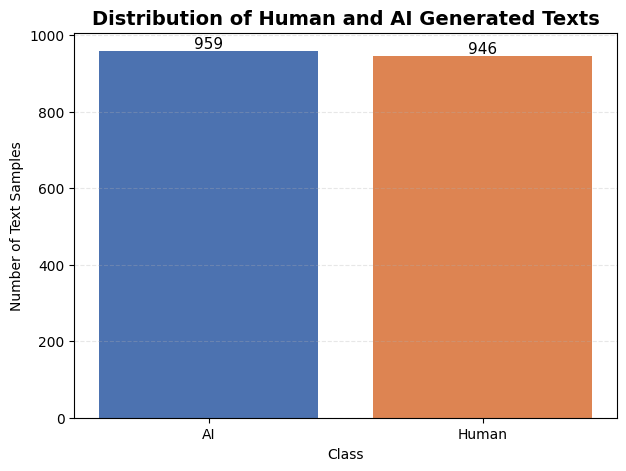

In [12]:
# -----------------------------------------------
# EDA-1: Human vs AI Text Distribution
# Goal: Analyse balance of dataset
# -----------------------------------------------


# count samples in each class
label_count = final_dataset['label'].value_counts()

# mapping labels
label_naming = {
    0: 'Human',
    1: 'AI'
}
label_count.index = label_count.index.map(label_naming)

# plot
plt.figure(figsize=(7,5))

colors = ['#4C72B0', '#DD8452']

bars = plt.bar(
    label_count.index,
    label_count.values,
    color = colors
)

# Add count values on top of bars
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width()/2,
      height,
      str(height),
      ha = 'center',
      va = 'bottom',
      fontsize=11
  )

plt.title(
    "Distribution of Human and AI Generated Texts",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Class")
plt.ylabel("Number of Text Samples")

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.show()

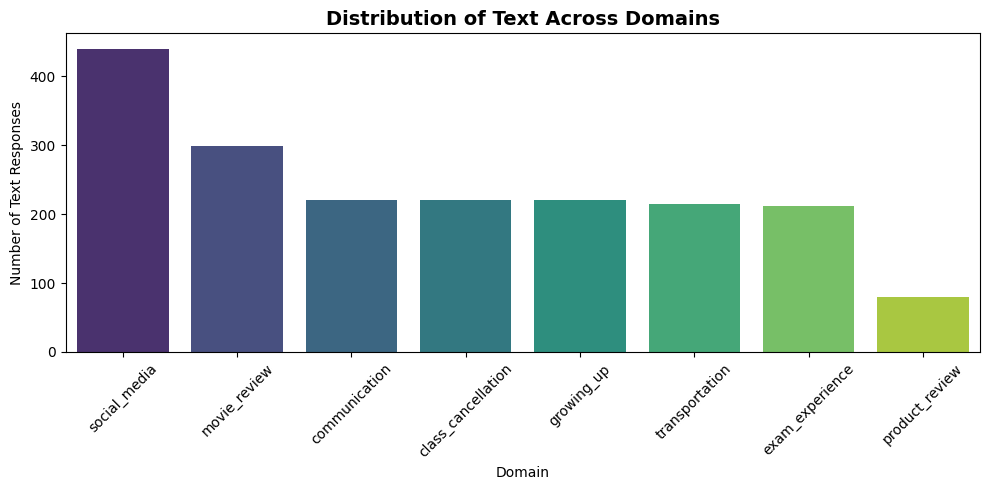

Domain Percentage Distribution:
domain
social_media          23.10
movie_review          15.70
communication         11.55
class_cancellation    11.55
growing_up            11.55
transportation        11.23
exam_experience       11.13
product_review         4.20
Name: count, dtype: float64


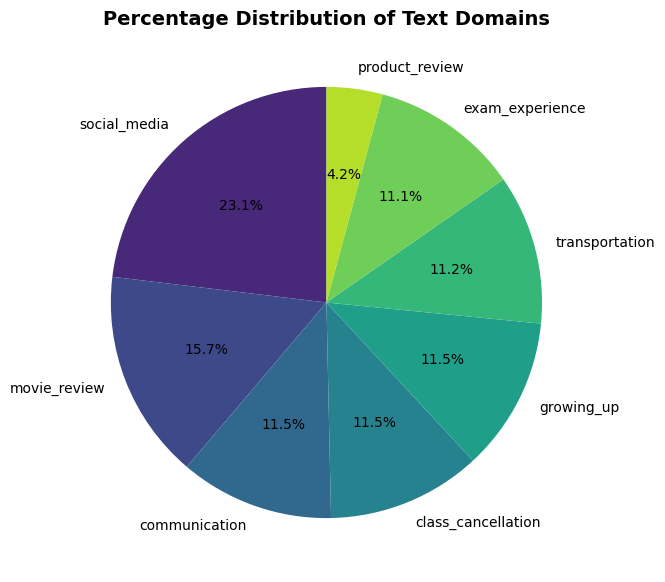

In [13]:
# -----------------------------------------------
# EDA-2: Domain Distribution
# Goal: Analyse distribution and diversity of text domains
# -----------------------------------------------


# Count each domain
domain_count = final_dataset['domain'].value_counts()


# Calculate percentage contribution
domain_percentage = (domain_count / len(final_dataset)) * 100


plt.figure(figsize=(10,5))


sns.barplot(
    x=domain_count.index,
    y=domain_count.values,
    palette='viridis'
)


plt.xlabel("Domain")
plt.ylabel("Number of Text Responses")


plt.title(
    "Distribution of Text Across Domains",
    fontsize=14,
    fontweight='bold'
)


plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


print("Domain Percentage Distribution:")
print(domain_percentage.round(2))


# -----------------------------------------------
# EDA-2: Domain Percentage Distribution
# Goal: Analyse percentage contribution of
# different text domains in the dataset
# -----------------------------------------------


domain_count = final_dataset['domain'].value_counts()


plt.figure(figsize=(7,7))


colors = sns.color_palette(
    'viridis',
    len(domain_count)
)


plt.pie(
    domain_count.values,
    labels=domain_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)


plt.title(
    "Percentage Distribution of Text Domains",
    fontsize=14,
    fontweight='bold'
)


plt.show()

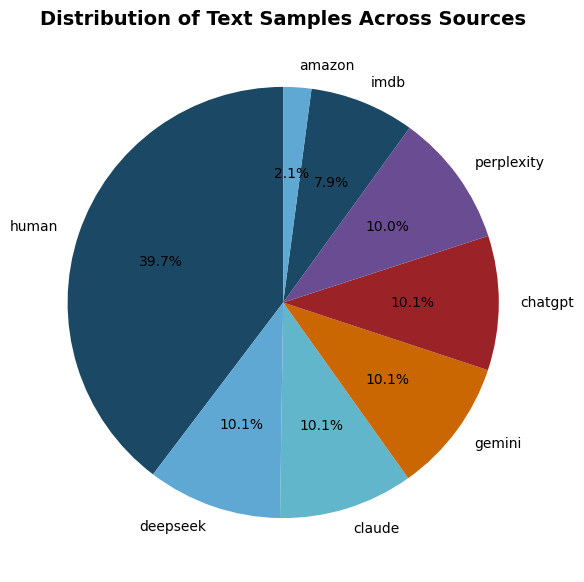

In [14]:
# -----------------------------------------------
# EDA-3: Source Distribution
# Goal: Analyse the contribution of different
# human and AI text sources in the dataset
# -----------------------------------------------

source_count = final_dataset['source'].value_counts()


plt.figure(figsize=(7,7))


colors = [
    "#1B4965",
    "#5FA8D3",
    "#62B6CB",
    "#CA6702",
    "#9B2226",
    "#6A4C93"
]


plt.pie(
    source_count.values,
    labels=source_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10}
)


plt.title(
    "Distribution of Text Samples Across Sources",
    fontsize=14,
    fontweight='bold'
)


plt.show()

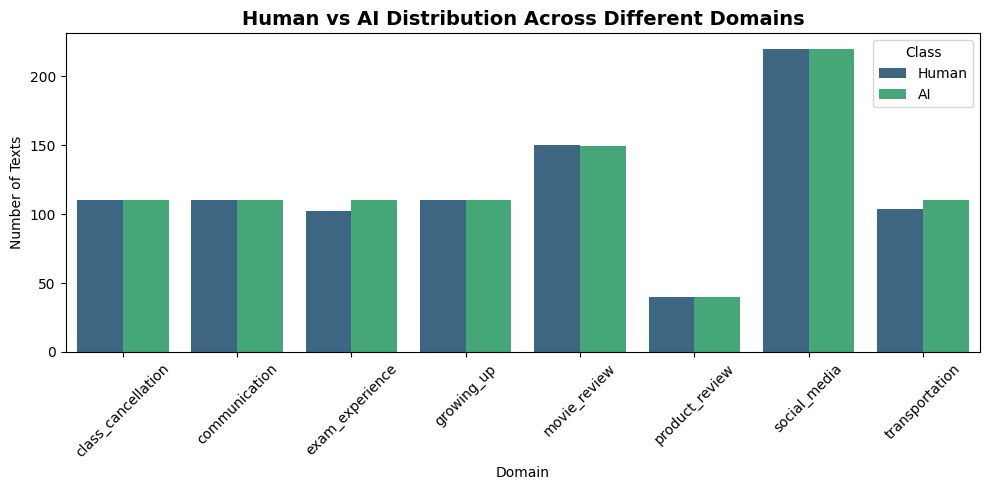

In [15]:
# -----------------------------------------------
# EDA-4: Domain-wise Human vs AI Distribution
# Goal: Analyse Human and AI text distribution
# across different domains
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------


domain_label_count = (
    final_dataset
    .groupby(['domain', 'label'])
    .size()
    .reset_index(name='count')
)


# Replace labels for better visualization
domain_label_count['class'] = domain_label_count['label'].map({
    0: 'Human',
    1: 'AI'
})


plt.figure(figsize=(10,5))


sns.barplot(
    data=domain_label_count,
    x='domain',
    y='count',
    hue='class',
    palette='viridis'
)


plt.xlabel("Domain")
plt.ylabel("Number of Texts")

plt.title(
    "Human vs AI Distribution Across Different Domains",
    fontsize=14,
    fontweight='bold'
)


plt.xticks(rotation=45)


plt.legend(
    title="Class"
)


plt.tight_layout()

plt.show()

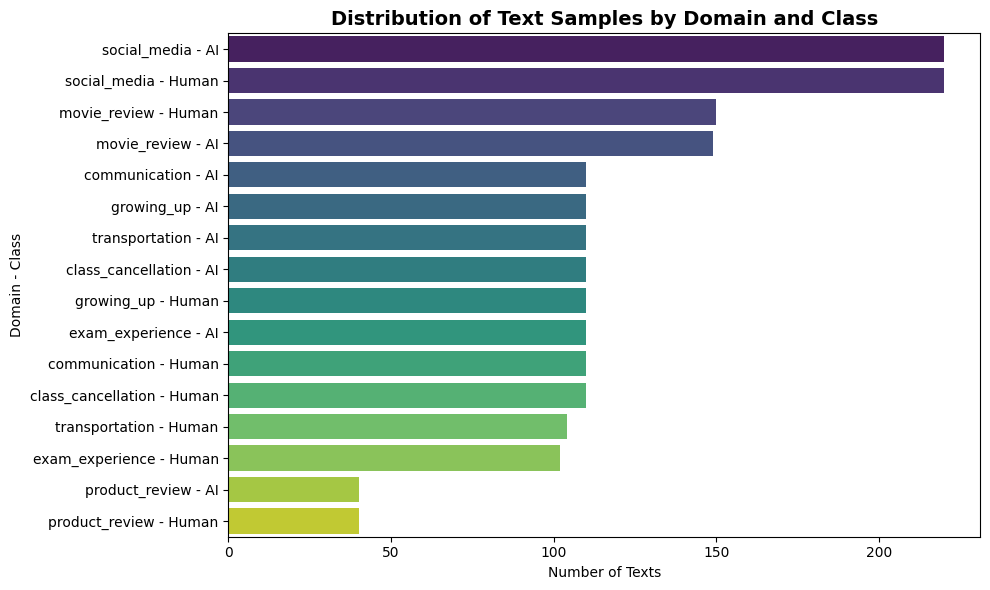

In [16]:
# -----------------------------------------------
# EDA-5: Domain + Label Combination Distribution
# Goal: Analyse detailed dataset composition by
# combining domain and class information
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------


# Create class names
final_dataset['class_name'] = final_dataset['label'].map({
    0: 'Human',
    1: 'AI'
})


# Combine domain and class
final_dataset['domain_class'] = (
    final_dataset['domain'] + " - " + final_dataset['class_name']
)


# Count each combination
domain_class_count = final_dataset['domain_class'].value_counts()

plt.figure(figsize=(10,6))


sns.barplot(
    x=domain_class_count.values,
    y=domain_class_count.index,
    palette='viridis'
)


plt.xlabel("Number of Texts")
plt.ylabel("Domain - Class")

plt.title(
    "Distribution of Text Samples by Domain and Class",
    fontsize=14,
    fontweight='bold'
)


plt.tight_layout()

plt.show()

            pronoun_count  unique_words  avg_word_length
class_name                                              
AI               3.233577     43.032325         5.136053
Human            4.043340     42.707188         4.473336


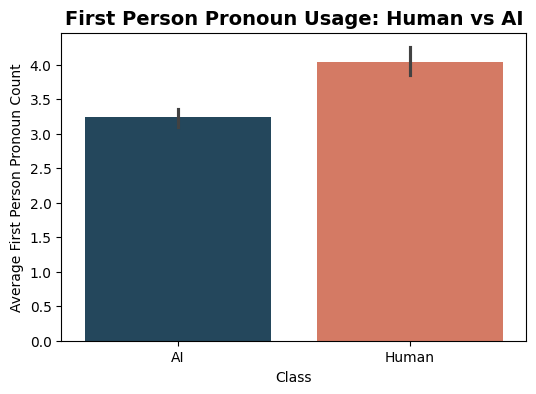

In [17]:
# -----------------------------------------------
# EDA-6: Writing Style Analysis
# Goal: Analyse linguistic differences between
# Human and AI-generated texts
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------


# Create class names
final_dataset['class_name'] = final_dataset['label'].map({
    0: 'Human',
    1: 'AI'
})


# First person pronouns
pronouns = ['i', 'my', 'me', 'we', 'our']


def count_pronouns(text):
    words = text.lower().split()
    return sum(words.count(word) for word in pronouns)


# Unique word count
def unique_word_count(text):
    words = text.lower().split()
    return len(set(words))


# Average word length
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)


# Apply features

final_dataset['pronoun_count'] = final_dataset['text'].apply(count_pronouns)

final_dataset['unique_words'] = final_dataset['text'].apply(unique_word_count)

final_dataset['avg_word_length'] = final_dataset['text'].apply(avg_word_length)


style_summary = final_dataset.groupby('class_name')[
    ['pronoun_count','unique_words','avg_word_length']
].mean()

print(style_summary)

plt.figure(figsize=(6,4))

sns.barplot(
    data=final_dataset,
    x='class_name',
    y='pronoun_count',
    palette=['#1B4965','#E76F51'],
    estimator='mean'
)


plt.xlabel("Class")
plt.ylabel("Average First Person Pronoun Count")

plt.title(
    "First Person Pronoun Usage: Human vs AI",
    fontsize=14,
    fontweight='bold'
)

plt.show()

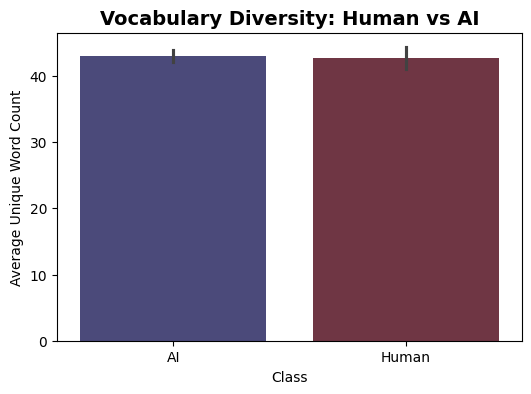

In [18]:
# -----------------------------------------------
# EDA-6.2: Unique Word Count Analysis
# Goal: Compare vocabulary diversity between
# Human and AI-generated texts
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------


plt.figure(figsize=(6,4))


sns.barplot(
    data=final_dataset,
    x='class_name',
    y='unique_words',
    palette='icefire',
    estimator='mean'
)


plt.xlabel("Class")
plt.ylabel("Average Unique Word Count")


plt.title(
    "Vocabulary Diversity: Human vs AI",
    fontsize=14,
    fontweight='bold'
)


plt.show()

     word     score
17   time  0.135920
4    feel  0.108656
10   like  0.103558
8    just  0.094409
9    life  0.083552
18    use  0.078413
0     bus  0.076857
6    good  0.074197
1   class  0.073031
2     don  0.071578
         word     score
11       just  0.154014
17       time  0.097976
6        feel  0.090249
13       like  0.086421
0         bus  0.071020
4         day  0.063713
18        use  0.062885
10   honestly  0.061462
2   childhood  0.058687
1   cancelled  0.058420


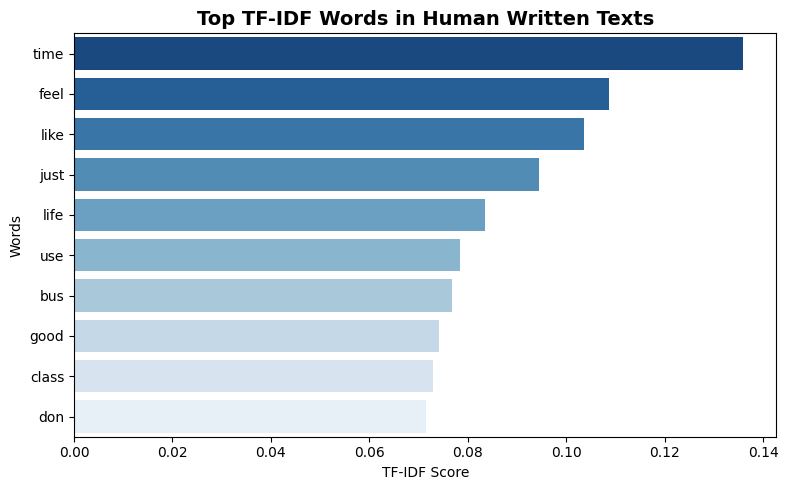

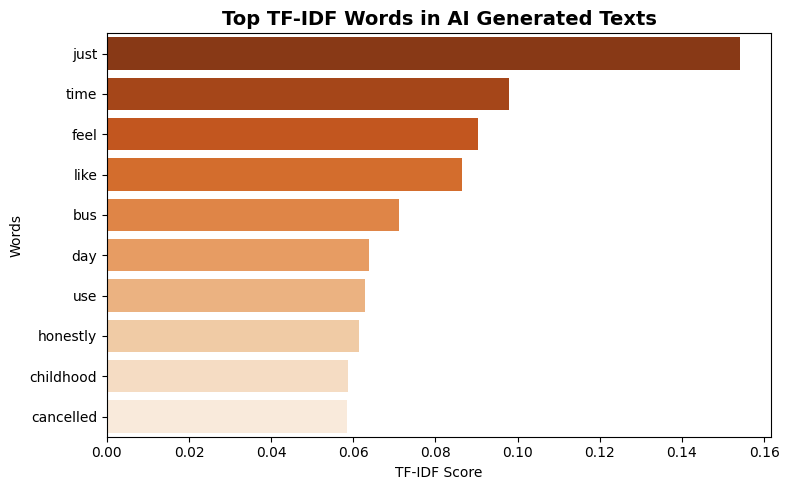

In [19]:
# -----------------------------------------------
# EDA-7: TF-IDF Top Features
# Goal: Identify important words that differentiate
# Human and AI-generated texts
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

# separate human and ai text
human_text = final_dataset[
    final_dataset['label'] == 0
]['text']

ai_text = final_dataset[
    final_dataset['label'] == 1
]['text']

tfidf = TfidfVectorizer(
    max_features=20,
    stop_words='english'
)

# apply tdf
human_tfidf = tfidf.fit_transform(human_text)

human_words = tfidf.get_feature_names_out()

# human top words
human_scores = human_tfidf.mean(axis=0).A1

human_features = pd.DataFrame({
    'word': human_words,
    'score': human_scores
})


human_features = human_features.sort_values(
    by='score',
    ascending=False
)

print(human_features.head(10))

# -----------------------------------------------
# EDA-7.2: AI Top TF-IDF Features
# Goal: Identify important words that represent
# AI-generated texts
#
# Class Mapping:
# 0 = Human
# 1 = AI
# -----------------------------------------------


# Select AI texts

ai_text = final_dataset[
    final_dataset['label'] == 1
]['text']


# Apply TF-IDF

tfidf_ai = TfidfVectorizer(
    max_features=20,
    stop_words='english'
)


ai_tfidf = tfidf_ai.fit_transform(ai_text)


# Get words

ai_words = tfidf_ai.get_feature_names_out()


# Calculate average TF-IDF score

ai_scores = ai_tfidf.mean(axis=0).A1


# Create dataframe

ai_features = pd.DataFrame({
    'word': ai_words,
    'score': ai_scores
})


# Sort by importance

ai_features = ai_features.sort_values(
    by='score',
    ascending=False
)


print(ai_features.head(10))

# -----------------------------------------------
# EDA-7.3: Human Top TF-IDF Words
# Goal: Visualize important words from Human texts
# -----------------------------------------------


plt.figure(figsize=(8,5))


sns.barplot(
    data=human_features.head(10),
    x='score',
    y='word',
    palette='Blues_r'
)


plt.xlabel("TF-IDF Score")
plt.ylabel("Words")


plt.title(
    "Top TF-IDF Words in Human Written Texts",
    fontsize=14,
    fontweight='bold'
)


plt.tight_layout()

plt.show()

# -----------------------------------------------
# EDA-7.4: AI Top TF-IDF Words
# Goal: Visualize important words from AI texts
# -----------------------------------------------


plt.figure(figsize=(8,5))


sns.barplot(
    data=ai_features.head(10),
    x='score',
    y='word',
    palette='Oranges_r'
)


plt.xlabel("TF-IDF Score")
plt.ylabel("Words")


plt.title(
    "Top TF-IDF Words in AI Generated Texts",
    fontsize=14,
    fontweight='bold'
)


plt.tight_layout()

plt.show()

# Text Preprocessing
Goal: Clean and normalize text data before
feature extraction and model training

In [20]:
clean_dataset = final_dataset.copy()


# Create new column for cleaned text
clean_dataset['clean_text'] = clean_dataset['text']


# lowercase conversion
clean_dataset['clean_text'] = (
    clean_dataset['clean_text']
    .str.lower()
)

# remove extra spaces and newlines
import re

def remove_extra_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


clean_dataset['clean_text'] = (
    clean_dataset['clean_text']
    .apply(remove_extra_spaces)
)

# remove special characters
def remove_special_characters(text):
    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        '',
        text
    )
    return text


clean_dataset['clean_text'] = (
    clean_dataset['clean_text']
    .apply(remove_special_characters)
)

# check before vs after
clean_dataset[['text','clean_text']].head()

,text,clean_text
0,When our Database Management Systems class get...,when our database management systems class get...
1,I have mixed feelings whenever our Operating S...,i have mixed feelings whenever our operating s...
2,"Honestly, when Statistics for Engineers got ca...",honestly when statistics for engineers got can...
3,"When our Psychology 101 lecture got scrapped, ...",when our psychology 101 lecture got scrapped i...
4,"Oh man, Advanced Calculus getting cancelled is...",oh man advanced calculus getting cancelled is ...


In [21]:
# check missing values
clean_dataset.isnull().sum()

# check empty text
empty_text = (
    clean_dataset['clean_text']
    .str.strip()
    .eq('')
    .sum()
)

print("Empty texts:", empty_text)

# text length after cleaning
clean_dataset['clean_length'] = (
    clean_dataset['clean_text']
    .apply(len)
)


clean_dataset['clean_length'].describe()

# compare before vs after
clean_dataset[['text','clean_text']].sample(5)


Empty texts: 0


,text,clean_text
707,It was the day I moved into my hostel room alo...,it was the day i moved into my hostel room alo...
1663,"Total panic mode first, but then pure survival...",total panic mode first but then pure survival ...
605,My daily commute involves navigating a rather ...,my daily commute involves navigating a rather ...
274,I often pause and reflect on why this small di...,i often pause and reflect on why this small di...
1853,"After watching this ""masterpiece"", I felt as i...",after watching this masterpiece i felt as if t...


#TF-IDF Feature Extraction
Goal: Convert cleaned text into numerical features so that ML models can learn patterns from Human and AI-generated texts.

In [22]:
# import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# separate input and label
X = clean_dataset['clean_text']
y = clean_dataset['label']

X.head()
y.value_counts()

,count
label,
1,959
0,946


In [23]:
# create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# transform text
X_tfidf = tfidf.fit_transform(X)
X_tfidf.shape

(1905, 5000)

#Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


Training data: (1524, 5000)
Testing data: (381, 5000)
Training labels: (1524,)
Testing labels: (381,)


#Model Training

# Baseline Model-1: Logistic Regression


In [25]:
# import model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# train model
lr_model.fit(X_train, y_train)

# predictions
predict_lr = lr_model.predict(X_test)

# check accuracy

lr_accuracy = accuracy_score(
    y_test,
    predict_lr
)

print("Logistic Regression Accuracy:", lr_accuracy*100,"%")

print(
    classification_report(
        y_test,
        predict_lr,
        target_names=['Human', 'AI']
    )
)

Logistic Regression Accuracy: 91.0761154855643 %
              precision    recall  f1-score   support

       Human       0.92      0.90      0.91       189
          AI       0.90      0.92      0.91       192

    accuracy                           0.91       381
   macro avg       0.91      0.91      0.91       381
weighted avg       0.91      0.91      0.91       381



confusion matrix

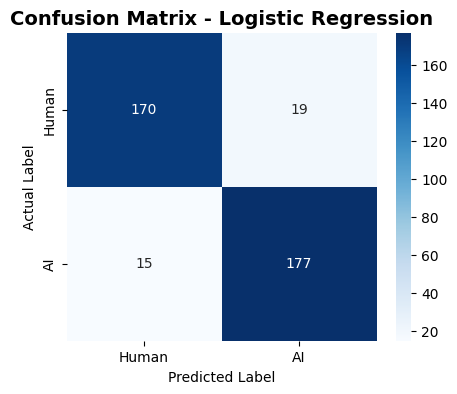

In [26]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    predict_lr
)


plt.figure(figsize=(5,4))


sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Human','AI'],
    yticklabels=['Human','AI']
)


plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")


plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=14,
    fontweight='bold'
)


plt.show()

# Baseline Model-2: SVM (Support vector machine)


In [27]:
# import svm
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

# train model
svm_model.fit(
    X_train,
    y_train
)

# prediction
predict_svm = svm_model.predict(X_test)

# check accuracy
svm_accuracy = accuracy_score(
    y_test,
    predict_svm
)

print("SVM Accuracy:", svm_accuracy*100,"%")

print(
    classification_report(
        y_test,
        predict_svm,
        target_names=['Human', 'AI']
    )
)


SVM Accuracy: 91.33858267716536 %
              precision    recall  f1-score   support

       Human       0.92      0.90      0.91       189
          AI       0.90      0.93      0.92       192

    accuracy                           0.91       381
   macro avg       0.91      0.91      0.91       381
weighted avg       0.91      0.91      0.91       381



Confusion matrix

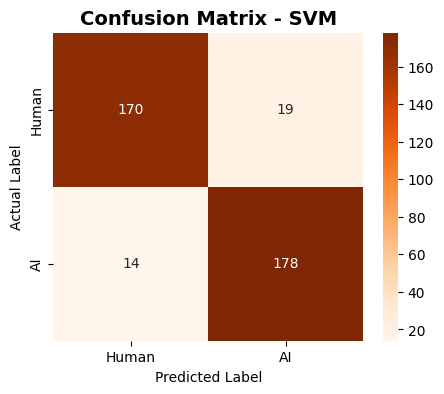

In [28]:
cm_svm = confusion_matrix(
    y_test,
    predict_svm
)


plt.figure(figsize=(5,4))


sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Human','AI'],
    yticklabels=['Human','AI']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "Confusion Matrix - SVM",
    fontsize=14,
    fontweight='bold'
)

plt.show()

In [29]:
baseline_result = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM'
    ],
    'Accuracy': [
        lr_accuracy,
        svm_accuracy
    ],
    'F1-score': [
        0.91,
        0.92
    ]
})

baseline_result

,Model,Accuracy,F1-score
0,Logistic Regression,0.910761,0.91
1,SVM,0.913386,0.92


# Advanced Model-1: DistilBERT


In [30]:
# -----------------------------------------------
# Advanced Model: DistilBERT
# Goal: Fine-tune transformer model for
# Human vs AI text classification
# -----------------------------------------------
# pip install transformers datasets accelerate -q


# import libraries
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)


# Load DistilBERT Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


##prepare dataset
Convert our dataframe into a format that HuggingFace Trainer can use for transformer training.


In [31]:
# -----------------------------------------------
# Prepare Dataset for DistilBERT
# Goal: Convert pandas dataframe into HuggingFace Dataset
# -----------------------------------------------

bert_dataset = clean_dataset[
    ['clean_text', 'label']
].copy()


# Convert pandas dataframe to HuggingFace Dataset

bert_dataset = Dataset.from_pandas(
    bert_dataset,
    preserve_index=False
)

bert_dataset

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 1905
})

In [32]:
# -----------------------------------------------
# Tokenization
# Goal: Convert text into DistilBERT input format
# -----------------------------------------------

def tokenize_data(batch):
    return tokenizer(
        batch['clean_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )


# Apply tokenizer

tokenized_dataset = bert_dataset.map(
    tokenize_data,
    batched=True
)


tokenized_dataset

Map:   0%|          | 0/1905 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 1905
})

In [33]:
# -----------------------------------------------
# Remove Unnecessary Column
# Goal: Keep only columns required for DistilBERT training
# -----------------------------------------------

tokenized_dataset = tokenized_dataset.remove_columns(
    ['clean_text']
)

tokenized_dataset



Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1905
})

# Train-Test Split
Goal: Create training and testing datasets

In [34]:
tokenized_dataset = tokenized_dataset.train_test_split(
    test_size=0.2,
    seed=42
)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1524
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 381
    })
})

# Load DistilBERT Model

Goal: Load pretrained DistilBERT and add a classification layer for 2 classes.
(Human vs AI text classification)

Classes:

0 → Human

1 → AI

In [35]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


print("DistilBERT model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully!


Training argument

In [36]:
!pip install -U transformers accelerate -q

In [40]:
# -----------------------------------------------
# Training Configuration
# Goal: Define hyperparameters for DistilBERT training
# -----------------------------------------------

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=20,

    report_to="none",

    seed=42
)

print("Training arguments created successfully!")

Training arguments created successfully!


Create Trainer

In [41]:
# -----------------------------------------------
# Create Trainer
# Goal: Initialize Trainer for DistilBERT
# -----------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"]
)

print("Trainer created successfully!")

Trainer created successfully!


Train the DistilBERT Model

In [42]:
# -----------------------------------------------
# Goal: Fine-tune DistilBERT on the training dataset
# -----------------------------------------------

trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.205692,0.232360
2,0.088526,0.197730
3,0.035759,0.195996


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=288, training_loss=0.18114205506733722, metrics={'train_runtime': 4035.2396, 'train_samples_per_second': 1.133, 'train_steps_per_second': 0.071, 'total_flos': 151410236663808.0, 'train_loss': 0.18114205506733722, 'epoch': 3.0})

## Model Evaluation - prediction

In [43]:
# -----------------------------------------------
# Model Evaluation
# Goal: Generate predictions on test dataset
# -----------------------------------------------

predictions = trainer.predict(
    tokenized_dataset["test"]
)

print("Prediction completed!")

Prediction completed!


In [44]:
# -----------------------------------------------
# Evaluation Metrics
# Goal: Calculate Accuracy, Precision, Recall and F1-score
# -----------------------------------------------

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report
)


# Convert logits to predicted labels

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)


# True labels

true_labels = predictions.label_ids


# Accuracy

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)


print("DistilBERT Accuracy:", accuracy*100, "%")


# Classification report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=['Human', 'AI']
    )
)

DistilBERT Accuracy: 93.96325459317585 %
              precision    recall  f1-score   support

       Human       0.93      0.96      0.94       197
          AI       0.95      0.92      0.94       184

    accuracy                           0.94       381
   macro avg       0.94      0.94      0.94       381
weighted avg       0.94      0.94      0.94       381



### Confusion matrix

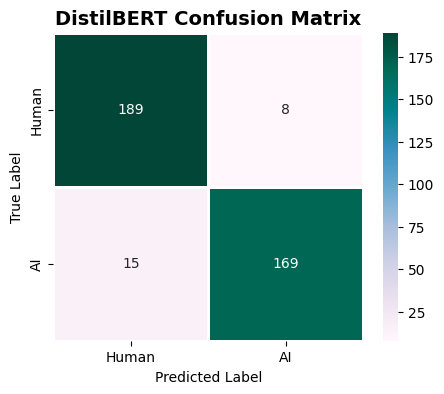

In [45]:
# -----------------------------------------------
# Confusion Matrix
# Goal: Visualize correct and incorrect predictions
# -----------------------------------------------

cm = confusion_matrix(
    true_labels,
    predicted_labels
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='PuBuGn',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI'],
    linewidths=1,
    linecolor='white'
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "DistilBERT Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.show()

# Final Model Comparison

In [46]:
# -----------------------------------------------
# Model Comparison
# Goal: Compare baseline and advanced models
# -----------------------------------------------

comparison_result = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'DistilBERT'
    ],

    'Accuracy': [
        lr_accuracy,
        svm_accuracy,
        accuracy
    ],

    'F1-score': [
        0.91,
        0.92,
        0.94
    ]

})


comparison_result

,Model,Accuracy,F1-score
0,Logistic Regression,0.910761,0.91
1,SVM,0.913386,0.92
2,DistilBERT,0.939633,0.94


### Model performance comparison chart

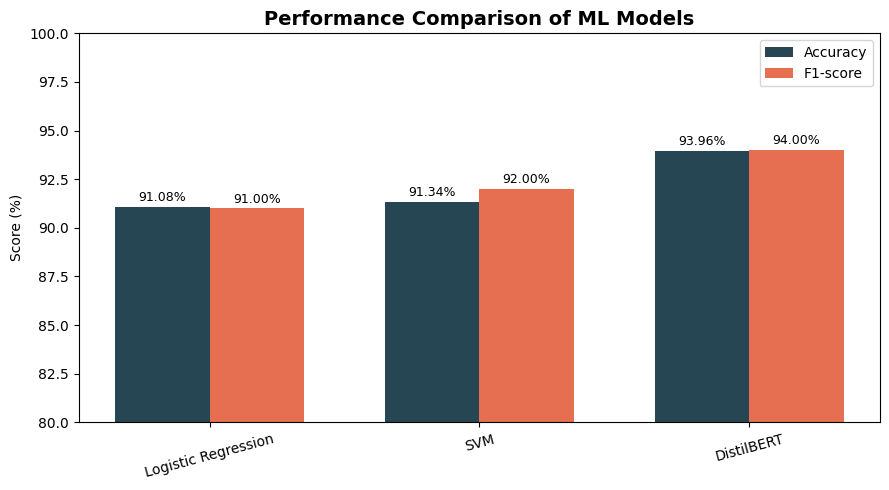

In [47]:
# -----------------------------------------------
# Model Performance Comparison
# Goal: Visualize accuracy and F1-score comparison
# -----------------------------------------------

models = comparison_result['Model']

accuracy_scores = comparison_result['Accuracy'] * 100
f1_scores = comparison_result['F1-score'] * 100


x = np.arange(len(models))
width = 0.35


plt.figure(figsize=(9,5))


plt.bar(
    x - width/2,
    accuracy_scores,
    width,
    label='Accuracy',
    color='#264653'
)


plt.bar(
    x + width/2,
    f1_scores,
    width,
    label='F1-score',
    color='#E76F51'
)


plt.xticks(
    x,
    models,
    rotation=15
)

plt.ylabel("Score (%)")

plt.ylim(80,100)

plt.title(
    "Performance Comparison of ML Models",
    fontsize=14,
    fontweight='bold'
)

for i, value in enumerate(accuracy_scores):
    plt.text(
        i - width/2,
        value + 0.3,
        f"{value:.2f}%",
        ha='center',
        fontsize=9
    )


for i, value in enumerate(f1_scores):
    plt.text(
        i + width/2,
        value + 0.3,
        f"{value:.2f}%",
        ha='center',
        fontsize=9
    )


plt.legend()

plt.tight_layout()

plt.show()

Save DistilBERT model

In [48]:
# -----------------------------------------------
# Save Fine-tuned DistilBERT Model
# Goal: Save trained model for future prediction
# -----------------------------------------------

model.save_pretrained(
    "./authentitext_distilbert"
)

tokenizer.save_pretrained(
    "./authentitext_distilbert"
)


print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


# Final Result Summary

In [49]:
# -----------------------------------------------
# Final Results Summary
# Goal: Create final performance summary table
# -----------------------------------------------

final_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "SVM",
        "DistilBERT"
    ],

    "Accuracy (%)": [
        round(lr_accuracy * 100, 2),
        round(svm_accuracy * 100, 2),
        round(accuracy * 100, 2)
    ],

    "F1-score": [
        0.91,
        0.92,
        0.94
    ]

})


final_results

,Model,Accuracy (%),F1-score
0,Logistic Regression,91.08,0.91
1,SVM,91.34,0.92
2,DistilBERT,93.96,0.94


# Error analysis

In [50]:
# -----------------------------------------------
# Error Analysis
# Goal: Analyze incorrectly classified samples
# -----------------------------------------------

# Create evaluation dataframe

error_analysis = pd.DataFrame({

    "text": [
        tokenized_dataset["test"][i]["input_ids"]
        for i in range(len(tokenized_dataset["test"]))
    ],

    "true_label": true_labels,

    "predicted_label": predicted_labels

})


# Find incorrect predictions

errors = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
]


print("Total Errors:", len(errors))

print(errors.head())

# -----------------------------------------------
# Display Misclassified Samples
# Goal: Convert token IDs back to readable text
# -----------------------------------------------

misclassified = []


for i in range(len(tokenized_dataset["test"])):

    if true_labels[i] != predicted_labels[i]:

        text = tokenizer.decode(
            tokenized_dataset["test"][i]["input_ids"],
            skip_special_tokens=True
        )

        misclassified.append({

            "Text": text,

            "Actual": "Human" if true_labels[i] == 0 else "AI",

            "Predicted": "Human" if predicted_labels[i] == 0 else "AI"

        })


error_df = pd.DataFrame(misclassified)


print(error_df.head(10))


Total Errors: 23
                                                 text  true_label  \
6   [101, 2012, 2034, 1045, 4687, 2065, 1045, 2056...           0   
7   [101, 2821, 2053, 1045, 2001, 2061, 6015, 1996...           1   
11  [101, 2591, 2865, 2038, 3271, 2033, 4553, 8425...           0   
54  [101, 1045, 8339, 2006, 2339, 1045, 4013, 2677...           1   
55  [101, 2026, 2567, 2515, 2023, 7887, 2002, 2015...           1   

    predicted_label  
6                 1  
7                 0  
11                1  
54                0  
55                0  
                                                Text Actual Predicted
0  at first i wonder if i said something wrong th...  Human        AI
1  oh no i was so scared the first time this happ...     AI     Human
2  social media has helped me learn graphic desig...  Human        AI
3  i reflect on why i procrastinated as i skim ur...     AI     Human
4  my brother does this constantly hes the king o...     AI     Human
5  i use youtube

#Interface


In [51]:
!zip -r authentitext_distilbert.zip authentitext_distilbert

  adding: authentitext_distilbert/ (stored 0%)
  adding: authentitext_distilbert/tokenizer_config.json (deflated 43%)
  adding: authentitext_distilbert/tokenizer.json (deflated 71%)
  adding: authentitext_distilbert/model.safetensors (deflated 8%)
  adding: authentitext_distilbert/config.json (deflated 49%)


In [52]:
from google.colab import files

files.download("authentitext_distilbert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
!pip install gradio transformers -q


In [54]:
import os

print(os.listdir("./authentitext_distilbert"))

['tokenizer_config.json', 'tokenizer.json', 'model.safetensors', 'config.json']


In [55]:
import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "./authentitext_distilbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.eval()

print("AuthentiText model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

AuthentiText model loaded successfully!


prediction function

In [56]:
def predict_text(text):

    if not text or not text.strip():
        return "Please enter some text.", {
            "Human": 0,
            "AI Generated": 0
        }

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)[0]

    human_probability = float(probabilities[0])
    ai_probability = float(probabilities[1])

    if ai_probability > human_probability:
        prediction = "AI Generated"
    else:
        prediction = "Human Written"

    return prediction, {
        "Human": human_probability,
        "AI Generated": ai_probability
    }

print("Prediction function ready!")

Prediction function ready!


gradio-UI

In [57]:
with gr.Blocks(title="AuthentiText") as demo:

    gr.Markdown(
        """
        # 🔍 AuthentiText
        ### Human vs AI-Generated Text Detection

        Enter a text below and let AuthentiText predict
        whether it is Human-written or AI-generated.
        """
    )

    text_input = gr.Textbox(
        label="Enter Your Text",
        placeholder="Paste or type your text here...",
        lines=8
    )

    analyze_button = gr.Button("🔍 Analyze Text")

    prediction_output = gr.Textbox(
        label="Prediction"
    )

    confidence_output = gr.Label(
        label="Confidence"
    )

    analyze_button.click(
        fn=predict_text,
        inputs=text_input,
        outputs=[
            prediction_output,
            confidence_output
        ]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b0785ce29c1e1ec1d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
